# 1. **Import Libraries**




In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. **Mount Google Drive**

In [65]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 3.**Load the Dataset**





In [66]:
df = pd.read_csv('/content/drive/MyDrive/Code Alpha Internship/Credit_Scoring_Model/german_credit_data.csv')

# 4. **Understanding the Dataset**


In [67]:
df.head() # Display first 5 rows

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [68]:
df.shape  # Check dataset dimensions

(1000, 11)

In [69]:
df.columns # Display column names

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [70]:
df.info() # Dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [71]:
df.describe() # Statistical summary

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [72]:
df.isnull().sum() # Check missing values

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


# 5. **Data Cleaning**



In [73]:
df.duplicated().sum() # Check duplicate rows

np.int64(0)

In [74]:
df.drop('Unnamed: 0', axis=1, inplace=True) # Remove unnecessary column

In [75]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [76]:
df.isnull().sum() # Check missing values

,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0
Risk,0


# 6. **Exploratory Data Analysis (EDA)**



# Age Distribution

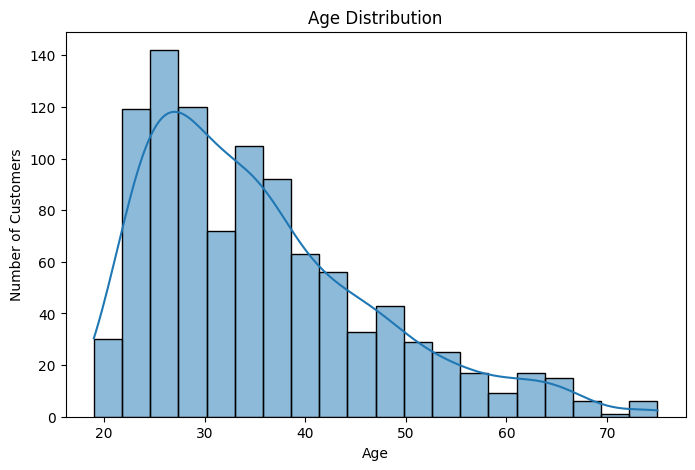

In [77]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

**Observation:**
- Most customers are between 20 and 40 years of age.
- Fewer customers belong to the older age groups.

# Gender Distribution

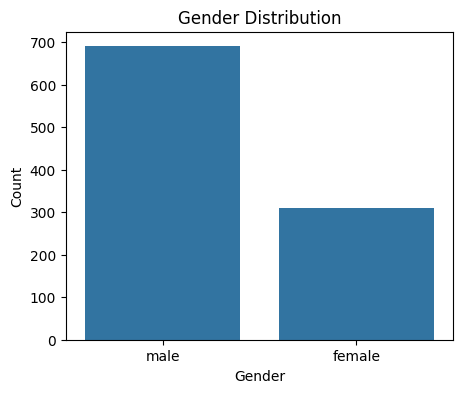

In [78]:
plt.figure(figsize=(5,4))
sns.countplot(x="Sex", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

**Observation:**
- Male customers are more than female customers in this dataset.

# Housing Distribution

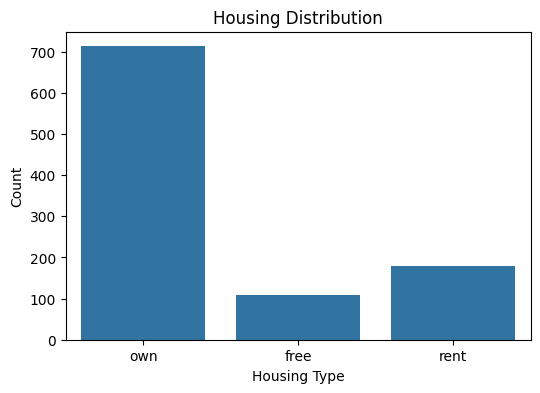

In [79]:
plt.figure(figsize=(6,4))
sns.countplot(x="Housing", data=df)

plt.title("Housing Distribution")
plt.xlabel("Housing Type")
plt.ylabel("Count")

plt.show()

**Observation:**
- Most customers own their houses.
- Fewer customers live in rented or free housing.

# Loan Purpose Distribution

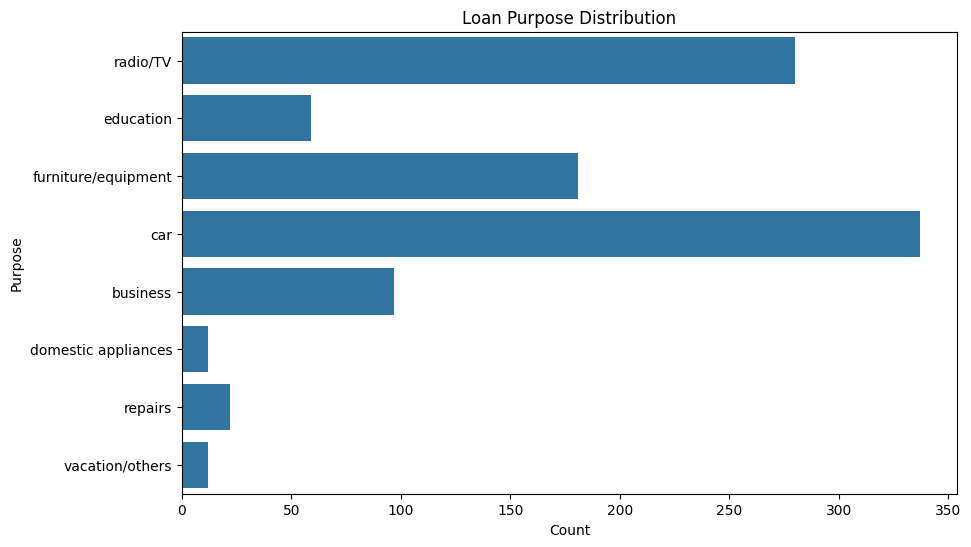

In [80]:
plt.figure(figsize=(10,6))
sns.countplot(y="Purpose", data=df)

plt.title("Loan Purpose Distribution")
plt.xlabel("Count")
plt.ylabel("Purpose")

plt.show()

**Observation:**
- Car, radio/TV, and furniture/equipment are the most common loan purposes.
- Some loan purposes have fewer applicants.

## Credit Amount Distribution

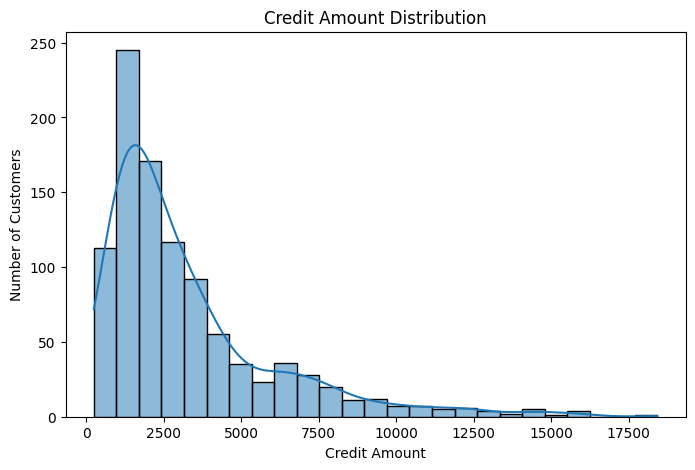

In [81]:
plt.figure(figsize=(8,5))
sns.histplot(df["Credit amount"], bins=25, kde=True)

plt.title("Credit Amount Distribution")
plt.xlabel("Credit Amount")
plt.ylabel("Number of Customers")

plt.show()

**Observation:**
- Most customers have lower credit amounts.
- Only a few customers have very high credit amounts.

# Loan Duration Distribution

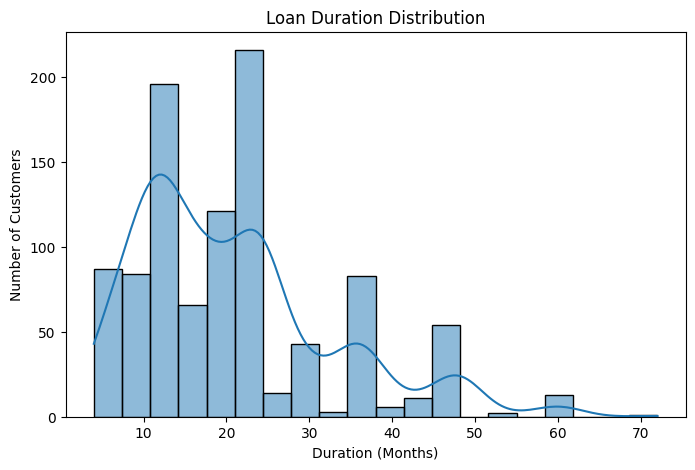

In [82]:
plt.figure(figsize=(8,5))
sns.histplot(df["Duration"], bins=20, kde=True)

plt.title("Loan Duration Distribution")
plt.xlabel("Duration (Months)")
plt.ylabel("Number of Customers")

plt.show()

**Observation:**
- Most loans have shorter repayment durations.
- Long-duration loans are less common.

# Risk Distribution

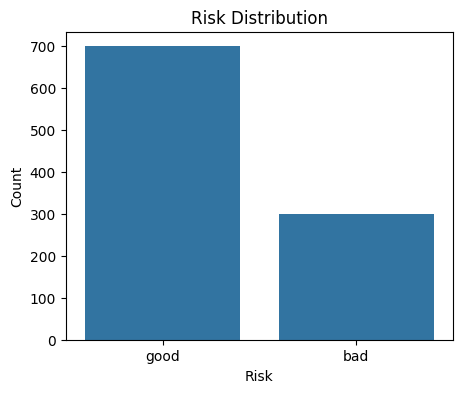

In [83]:
plt.figure(figsize=(5,4))

sns.countplot(x="Risk", data=df)

plt.title("Risk Distribution")
plt.xlabel("Risk")
plt.ylabel("Count")

plt.show()

**Observation:**

- The dataset contains more customers with good credit risk than bad credit risk.
- This indicates that the majority of customers are classified as good credit applicants.

#Correlation Heatmap

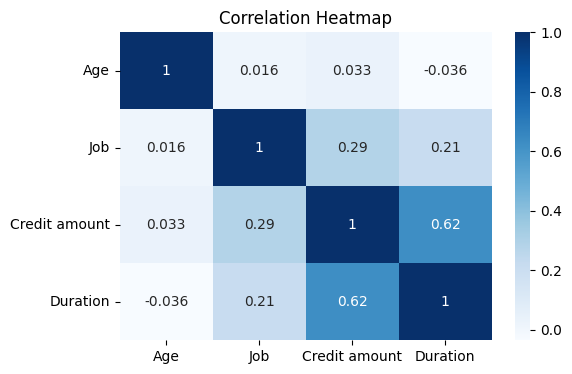

In [84]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")

plt.title("Correlation Heatmap")

plt.show()

**Observation:**
- Most numerical features have weak to moderate correlation.
- No strong relationship exists between the numerical variables.

# 7. **Data Preprocessing**



# Handle Missing Values

In [85]:
df.isnull().sum()

,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0
Risk,0


In [86]:
#Fill missing values
df["Saving accounts"].fillna("Unknown", inplace=True)
df["Checking account"].fillna("Unknown", inplace=True)

/tmp/ipykernel_856/96696698.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Saving accounts"].fillna("Unknown", inplace=True)
/tmp/ipykernel_856/96696698.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [87]:
# Verify Missing Values
df.isnull().sum()

,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Purpose,0
Risk,0


**Observation:**
All missing values have been handled successfully.

# Convert Categorical Data into Numerical Data

In [88]:
df = pd.get_dummies(df, drop_first=True)

# Verify the Dataset

In [89]:
df.head()

,Age,Job,Credit amount,Duration,Sex_male,Housing_own,Housing_rent,Saving accounts_little,Saving accounts_moderate,Saving accounts_quite rich,...,Checking account_moderate,Checking account_rich,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Risk_good
0,67,2,1169,6,True,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,22,2,5951,48,False,True,False,True,False,False,...,True,False,False,False,False,False,True,False,False,False
2,49,1,2096,12,True,True,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
3,45,2,7882,42,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,True
4,53,2,4870,24,True,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False


# Check Data Types

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Age                          1000 non-null   int64
 1   Job                          1000 non-null   int64
 2   Credit amount                1000 non-null   int64
 3   Duration                     1000 non-null   int64
 4   Sex_male                     1000 non-null   bool 
 5   Housing_own                  1000 non-null   bool 
 6   Housing_rent                 1000 non-null   bool 
 7   Saving accounts_little       1000 non-null   bool 
 8   Saving accounts_moderate     1000 non-null   bool 
 9   Saving accounts_quite rich   1000 non-null   bool 
 10  Saving accounts_rich         1000 non-null   bool 
 11  Checking account_little      1000 non-null   bool 
 12  Checking account_moderate    1000 non-null   bool 
 13  Checking account_rich        1000 non-null   bool

# 8. **Feature Selection**



# Define Features and Target


In [91]:
# Separate features and target
X = df.drop("Risk_good", axis=1)
y = df["Risk_good"]

In [92]:
# Display feature columns
X.head()

,Age,Job,Credit amount,Duration,Sex_male,Housing_own,Housing_rent,Saving accounts_little,Saving accounts_moderate,Saving accounts_quite rich,...,Checking account_little,Checking account_moderate,Checking account_rich,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,2,1169,6,True,True,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False
1,22,2,5951,48,False,True,False,True,False,False,...,False,True,False,False,False,False,False,True,False,False
2,49,1,2096,12,True,True,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
3,45,2,7882,42,True,False,False,True,False,False,...,True,False,False,False,False,False,True,False,False,False
4,53,2,4870,24,True,False,False,True,False,False,...,True,False,False,True,False,False,False,False,False,False


In [93]:
# Display target values
y.head()

,Risk_good
0,True
1,False
2,True
3,True
4,False


**Observation:**

The dataset has been successfully divided into features (X) and the target variable (y).

# Check Dataset Shapes


In [94]:
# Display shapes of features and target
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1000, 21)
Target Shape: (1000,)


**Observation:**

The feature matrix and target variable have the correct dimensions for model training.

# 9. **Train-Test Split**



# Import Required Library

In [95]:
from sklearn.model_selection import train_test_split

# Split the Dataset

In [96]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [97]:
# Display shapes of training and testing data
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (800, 21)
X_test : (200, 21)
y_train: (800,)
y_test : (200,)


**Observation:**

The dataset has been successfully divided into training and testing sets. The training data will be used to build the model, while the testing data will be used to evaluate its performance.

# 10. **Logistic Regression Model**


# Import Required Libraries

In [98]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train the Logistic Regression Model

In [99]:
# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

**Observation:**

The Logistic Regression model has been successfully trained using the training dataset.

# Make Predictions

In [100]:
# Predict on test data
y_pred_lr = lr_model.predict(X_test)

**Observation:**

The model has generated predictions for the testing dataset.

# Model Accuracy

In [101]:
# Calculate accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.75


**Observation:**

The accuracy score indicates how well the Logistic Regression model predicts credit risk.

# Confusion Matrix

In [102]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[ 22  37]
 [ 13 128]]


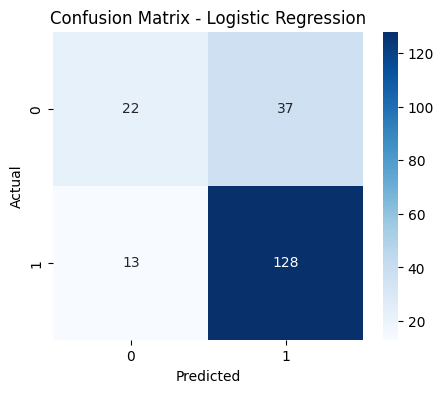

In [103]:
plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Observation:**

The confusion matrix shows the number of correctly and incorrectly classified credit risk predictions.

# Classification Report

In [104]:
# Display classification report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

       False       0.63      0.37      0.47        59
        True       0.78      0.91      0.84       141

    accuracy                           0.75       200
   macro avg       0.70      0.64      0.65       200
weighted avg       0.73      0.75      0.73       200



**Observation:**

The classification report provides detailed performance metrics, including precision, recall, F1-score, and overall accuracy.

# 11. **Decision Tree Classifier**

# Import Required Library



In [105]:
from sklearn.tree import DecisionTreeClassifier

# Train the Decision Tree Model

In [106]:
# Create Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

**Observation:**

The Decision Tree model has been successfully trained using the training dataset.

# Make Predictions



In [107]:
# Predict on test data
y_pred_dt = dt_model.predict(X_test)

**Observation:**

The Decision Tree model has generated predictions for the testing dataset.

# Model Accuracy

In [108]:
# Calculate accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.675


**Observation:**

The accuracy score indicates how well the Decision Tree model predicts credit risk.

# Confusion Matrix

In [109]:
# Generate confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[ 29  30]
 [ 35 106]]


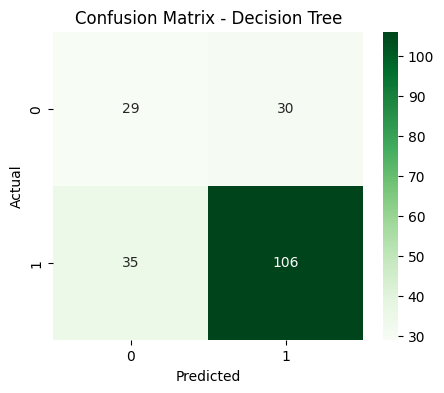

In [110]:
# Visualize confusion matrix
plt.figure(figsize=(5,4))

sns.heatmap(cm_dt,
            annot=True,
            fmt="d",
            cmap="Greens")

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Observation:**

The confusion matrix shows the number of correct and incorrect predictions made by the Decision Tree model.

# Classification Report

In [111]:
# Display classification report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

       False       0.45      0.49      0.47        59
        True       0.78      0.75      0.77       141

    accuracy                           0.68       200
   macro avg       0.62      0.62      0.62       200
weighted avg       0.68      0.68      0.68       200



**Observation:**

The classification report provides detailed evaluation metrics for the Decision Tree model.

#12. **Random Forest Classifier**


# Import Required Library

In [112]:
from sklearn.ensemble import RandomForestClassifier

# Train the Random Forest Model


In [113]:
# Create Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**Observation:**

The Random Forest model has been successfully trained using the training dataset.

# Make Predictions


In [114]:
# Predict on test data
y_pred_rf = rf_model.predict(X_test)

**Observation:**

The Random Forest model has generated predictions for the testing dataset.

# Model Accuracy


In [115]:
# Calculate accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.745


**Observation:**

The accuracy score indicates how well the Random Forest model predicts credit risk.

# Confusion Matrix

In [116]:
# Generate confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[ 20  39]
 [ 12 129]]


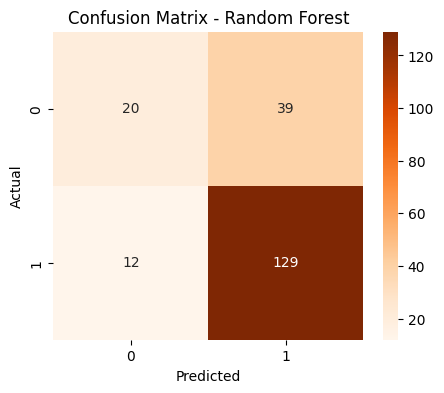

In [117]:
# Visualize confusion matrix
plt.figure(figsize=(5,4))

sns.heatmap(cm_rf,
            annot=True,
            fmt="d",
            cmap="Oranges")

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Observation:**

The confusion matrix shows the number of correctly and incorrectly classified instances by the Random Forest model.

# Classification Report

In [118]:
# Display classification report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

       False       0.62      0.34      0.44        59
        True       0.77      0.91      0.83       141

    accuracy                           0.74       200
   macro avg       0.70      0.63      0.64       200
weighted avg       0.73      0.74      0.72       200



**Observation:**

The classification report provides detailed evaluation metrics for the Random Forest model.

# 13. **Model Comparison**


# Compare Model Accuracy



In [119]:
# Create a comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.750
1,Decision Tree,0.675
2,Random Forest,0.745


**Observation:**

The table compares the accuracy of all three machine learning models.

# Visualize Model Performance


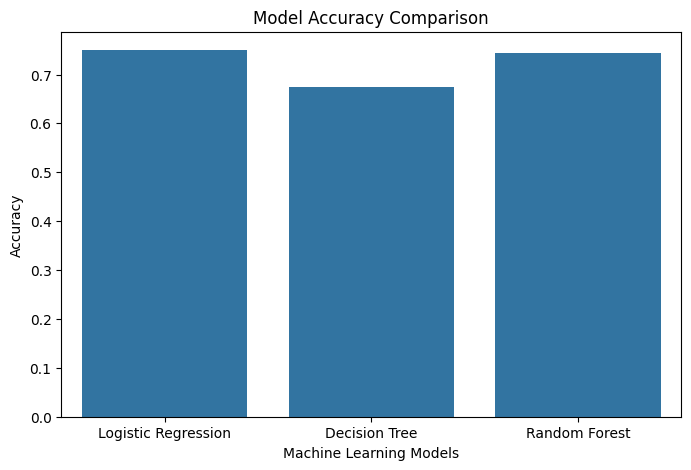

In [120]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=model_comparison
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")

plt.show()

**Observation:**

The bar chart clearly shows the performance of each machine learning model based on accuracy.



# Best Performing Model



In [121]:
best_model = model_comparison.loc[
    model_comparison["Accuracy"].idxmax()
]

print(best_model)

Model       Logistic Regression
Accuracy                   0.75
Name: 0, dtype: object


In [122]:
print("Best Model :", best_model["Model"])
print("Accuracy   :", round(best_model["Accuracy"], 4))

Best Model : Logistic Regression
Accuracy   : 0.75


**Observation:**

The model with the highest accuracy is selected as the best-performing model for this project.

# 14. **Save the Best Model**



# Import Joblib



In [123]:
import joblib

# Save the Best Model



In [124]:
# Save the Logistic Regression model
joblib.dump(lr_model, "credit_scoring_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# Verify Saved Model



In [125]:
# Load the saved model
loaded_model = joblib.load("credit_scoring_model.pkl")

print(loaded_model)

LogisticRegression(max_iter=1000)


**Observation:**

The best-performing model has been successfully saved and loaded for future predictions.

# 15. **Conclusion**

In this project, a Credit Scoring Model was developed using machine learning techniques. The dataset was explored, cleaned, and preprocessed before training the models. Three classification models—Logistic Regression, Decision Tree, and Random Forest—were trained and evaluated. Based on the accuracy results, Logistic Regression achieved the best performance for this dataset. Finally, the best model was saved for future predictions.

In [127]:
from google.colab import files

files.download("credit_scoring_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>